Name- Vaishnavi Pulikkal  
Section- B4   Batch- B2  
Roll No- 20  
SPL Project

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**1] Dataset Loading and Exploration**

In [44]:
df=pd.read_csv('/content/electric_bill_data.csv')
df.head()

,Unnamed: 0,num_rooms,num_people,housearea,is_ac,is_tv,is_flat,ave_monthly_income,num_children,is_urban,amount_paid
0,0,3,3,742.57,Yes,Yes,Flat,9675.93,2,Rural,1681.444341
1,1,1,5,952.99,No,Yes,Not Flat,35064.79,1,Urban,1899.851036
2,2,3,1,761.44,Yes,Yes,Flat,22292.44,0,Rural,1535.637470
3,3,0,5,861.32,Yes,Yes,Not Flat,12139.08,0,Rural,998.976106
4,4,1,8,731.61,No,Yes,Not Flat,17230.10,2,Urban,1974.856875


In [45]:
print('Column Names:\n',df.columns)

Column Names:
 Index(['Unnamed: 0', 'num_rooms', 'num_people', 'housearea', 'is_ac', 'is_tv',
       'is_flat', 'ave_monthly_income', 'num_children', 'is_urban',
       'amount_paid'],
      dtype='object')


In [46]:
print('Number of rows and columns=',df.shape)
print('Datatypes:\n',df.dtypes)

Number of rows and columns= (2000, 11)
Datatypes:
 Unnamed: 0              int64
num_rooms               int64
num_people              int64
housearea             float64
is_ac                  object
is_tv                  object
is_flat                object
ave_monthly_income    float64
num_children            int64
is_urban               object
amount_paid           float64
dtype: object


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          2000 non-null   int64  
 1   num_rooms           2000 non-null   int64  
 2   num_people          2000 non-null   int64  
 3   housearea           2000 non-null   float64
 4   is_ac               2000 non-null   object 
 5   is_tv               2000 non-null   object 
 6   is_flat             2000 non-null   object 
 7   ave_monthly_income  2000 non-null   float64
 8   num_children        2000 non-null   int64  
 9   is_urban            2000 non-null   object 
 10  amount_paid         2000 non-null   float64
dtypes: float64(3), int64(4), object(4)
memory usage: 172.0+ KB


In [48]:
df.describe()

,Unnamed: 0,num_rooms,num_people,housearea,ave_monthly_income,num_children,amount_paid
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,999.500000,1.962000,4.897000,794.70342,24684.986550,1.078000,1801.189078
std,577.494589,1.030091,2.007089,147.73477,9675.807154,0.933998,544.082489
min,0.000000,-1.000000,-1.000000,244.40000,-1576.440000,0.000000,263.555549
25%,499.750000,1.000000,4.000000,691.03750,18036.762500,0.000000,1425.195423
50%,999.500000,2.000000,5.000000,789.97000,24742.575000,1.000000,1794.995177
75%,1499.250000,3.000000,6.000000,892.95500,31402.357500,2.000000,2189.791466
max,1999.000000,5.000000,11.000000,1189.12000,56531.080000,4.000000,3308.982327


**2] Data Preprocessing**

Missing Values and Duplicate Values

In [49]:
print('Missing values in the dataset:\n',df.isnull().sum())

Missing values in the dataset:
 Unnamed: 0            0
num_rooms             0
num_people            0
housearea             0
is_ac                 0
is_tv                 0
is_flat               0
ave_monthly_income    0
num_children          0
is_urban              0
amount_paid           0
dtype: int64


In [50]:
print('Duplicate values in the dataset:',df.duplicated().sum())

Duplicate values in the dataset: 0


Statistical Analysis

In [51]:
print('House Area Statistical Analysis:')
print("Mean=",df['housearea'].mean())
print("Median=",df['housearea'].median())
print("Mode=",df['housearea'].mode()[0])
print("Variance=", df['housearea'].var())
print("Standard Deviation=", df['housearea'].std())

House Area Statistical Analysis:
Mean= 794.7034199999999
Median= 789.97
Mode= 631.54
Variance= 21825.5622736404
Standard Deviation= 147.73477002263346


In [52]:
print('Statistical Analysis of amount paid by each household for Electricity:')
print('Mean=',df['amount_paid'].mean())
print('Median=',df['amount_paid'].median())
print('Mode=',df['amount_paid'].mode()[0])
print('Variance=',df['amount_paid'].var())
print('Standard Deviation=',df['amount_paid'].std())

Statistical Analysis of amount paid by each household for Electricity:
Mean= 1801.18907797974
Median= 1794.9951769499999
Mode= 263.5555491
Variance= 296025.75512821996
Standard Deviation= 544.082489268144


Visualization

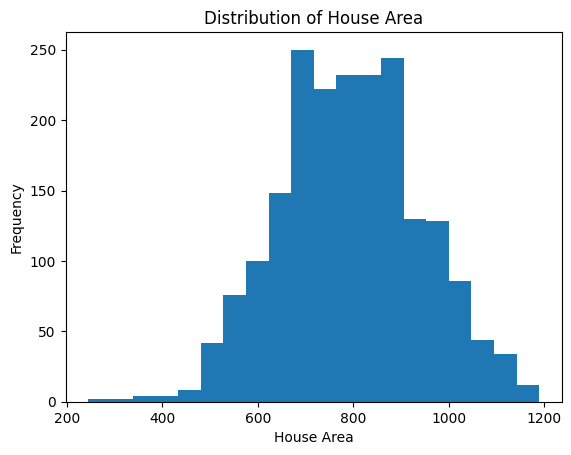

In [53]:
plt.hist(df['housearea'], bins=20)
plt.title("Distribution of House Area")
plt.xlabel("House Area")
plt.ylabel("Frequency")
plt.show()

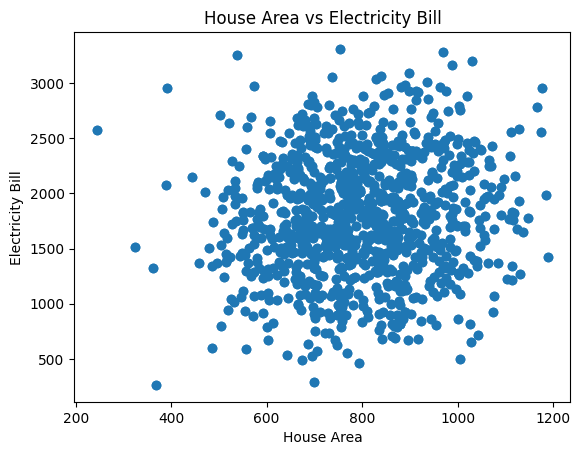

In [54]:
plt.scatter(df['housearea'], df['amount_paid'])
plt.xlabel("House Area")
plt.ylabel("Electricity Bill")
plt.title("House Area vs Electricity Bill")
plt.show()

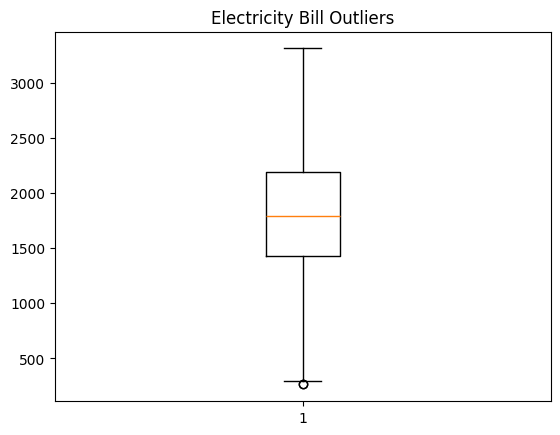

In [55]:
plt.boxplot(df['amount_paid'])
plt.title("Electricity Bill Outliers")
plt.show()

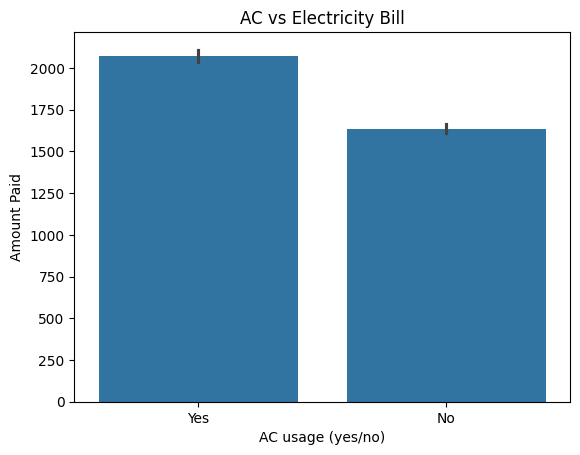

In [56]:
sns.barplot(x='is_ac', y='amount_paid', data=df)
plt.title("AC vs Electricity Bill")
plt.xlabel('AC usage (yes/no)')
plt.ylabel('Amount Paid')
plt.show()

Detecting Outliers

In [57]:
Q1 = df['amount_paid'].quantile(0.25)
Q3 = df['amount_paid'].quantile(0.75)
IQR = Q3 - Q1
print("Q1=", Q1)
print("Q3=", Q3)
print("IQR=", IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['amount_paid'] < lower_bound) | (df['amount_paid'] > upper_bound)]
print("Outliers:")
outliers

Q1= 1425.1954233000001
Q3= 2189.79146595
IQR= 764.5960426500001
Outliers:


,Unnamed: 0,num_rooms,num_people,housearea,is_ac,is_tv,is_flat,ave_monthly_income,num_children,is_urban,amount_paid
932,932,2,5,367.73,No,No,Not Flat,14814.95,0,Rural,263.555549
1932,1932,2,5,367.73,No,No,Not Flat,14814.95,0,Rural,263.555549


In [58]:
#removing outliers
df = df[(df['amount_paid'] >= lower_bound) & (df['amount_paid'] <= upper_bound)]

Label Encoding

In [59]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['is_ac']=le.fit_transform(df['is_ac'])
df['is_flat']=le.fit_transform(df['is_flat'])
df['is_tv']=le.fit_transform(df['is_tv'])
df['is_urban']=le.fit_transform(df['is_urban'])
df.head()

,Unnamed: 0,num_rooms,num_people,housearea,is_ac,is_tv,is_flat,ave_monthly_income,num_children,is_urban,amount_paid
0,0,3,3,742.57,1,1,0,9675.93,2,0,1681.444341
1,1,1,5,952.99,0,1,1,35064.79,1,1,1899.851036
2,2,3,1,761.44,1,1,0,22292.44,0,0,1535.637470
3,3,0,5,861.32,1,1,1,12139.08,0,0,998.976106
4,4,1,8,731.61,0,1,1,17230.10,2,1,1974.856875


Two Sample t-test

In [60]:
from scipy import stats
ac = df[df['is_ac'] == 1]['amount_paid']
no_ac = df[df['is_ac'] == 0]['amount_paid']
t_stat, p_value = stats.ttest_ind(ac, no_ac)
print("t-stat=", t_stat)
print("p-value=", p_value)

t-stat= 18.892733292499265
p-value= 2.2570744929656642e-73


In [61]:
if p_value<0.05:
  print('Reject Null Hypothesis')
else:
  print('Fail to reject null Hypothesis')

Reject Null Hypothesis


This shows that there is a significant difference between electricty bill of households that use AC and households that do not use AC, proving that AC usage has an impact on the electricity bill.



Feature Engineering

In [62]:
df['appliance_score'] = df['is_ac'] + df['is_tv']
df.head()

,Unnamed: 0,num_rooms,num_people,housearea,is_ac,is_tv,is_flat,ave_monthly_income,num_children,is_urban,amount_paid,appliance_score
0,0,3,3,742.57,1,1,0,9675.93,2,0,1681.444341,2
1,1,1,5,952.99,0,1,1,35064.79,1,1,1899.851036,1
2,2,3,1,761.44,1,1,0,22292.44,0,0,1535.637470,2
3,3,0,5,861.32,1,1,1,12139.08,0,0,998.976106,2
4,4,1,8,731.61,0,1,1,17230.10,2,1,1974.856875,1


A new feature appliance_score was created by combining AC and TV usage to better represent the overall impact of appliances on electricity consumption.

Covariance and Correlation

In [63]:
covariance=np.cov(df['housearea'],df['amount_paid'])[0,1]
print('Covariance=',covariance)

Covariance= 7078.61978562245


The positive covariance indicates that as house area increases, the electricity bill tends to increase.

In [64]:
correlation=np.corrcoef(df['appliance_score'],df['amount_paid'])[0,1]
print('Correlation=',correlation)

Correlation= 0.42357783684167427


The correlation is moderately positive, indicating that higher appliance usage leads to an increase in electricity bill.

In [65]:
corr_matrix=df[['ave_monthly_income','amount_paid']].corr()
print('Correlation Matrix=\n',corr_matrix)

Correlation Matrix=
                     ave_monthly_income  amount_paid
ave_monthly_income            1.000000     0.023106
amount_paid                   0.023106     1.000000


The correlation is very low, indicating that monthly income has a negligible effect on the electricity bill.

Text(0.5, 1.0, 'Heatmap for correlation matrix')

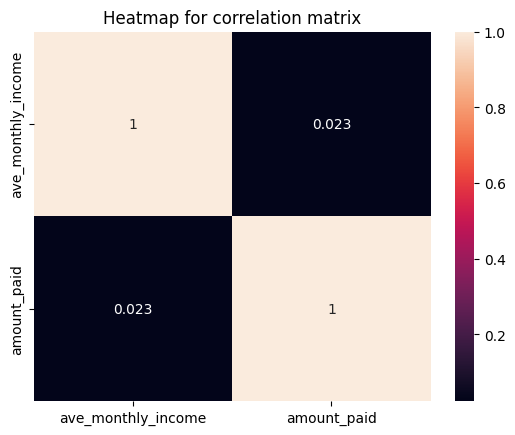

In [66]:
import seaborn as sns
sns.heatmap(corr_matrix,annot=True)
plt.title('Heatmap for correlation matrix')

Text(0.5, 1.0, 'Correlation between house area and amount paid')

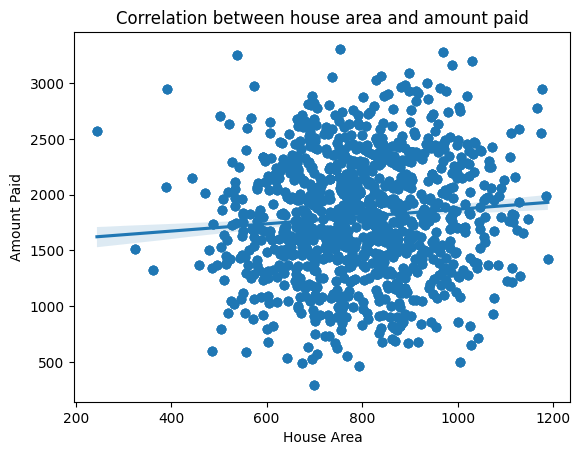

In [67]:
plt.scatter(df['housearea'],df['amount_paid'])
sns.regplot(x='housearea',y='amount_paid',data=df)
plt.xlabel('House Area')
plt.ylabel('Amount Paid')
plt.title('Correlation between house area and amount paid')

In [68]:
#Pearson correlation test
from scipy import stats
r,p_value=stats.pearsonr(df['housearea'],df['amount_paid'])
print('Pearson Correlation r=',r)
print('P- value=',p_value)

Pearson Correlation r= 0.0887022160823048
P- value= 7.179834600547151e-05


In [69]:
if p_value<0.05:
  print('Significant correlation exists')
else:
  print('No Significant correlation')

Significant correlation exists


Although statistically significant, the weak correlation suggests that housearea alone is not a strong predictor of electricity bills. It may need to be combined with other variables.

In [70]:
#spearman Correlation
rho,p_spearman=stats.spearmanr(df['housearea'],df['amount_paid'])
print('Spearman correlation (rho)=',rho)
print('P-value=',p_spearman)

Spearman correlation (rho)= 0.08764064127175199
P-value= 8.76180542106024e-05


In [71]:
if p_value<0.05:
  print('Significant correlation exists')
else:
  print('No Significant correlation')

Significant correlation exists


A weak but significant  relationship exists. As house area increases, electricity bills tend to increase slightly, but the effect is small.

Electrity Bill Prediction System

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,VotingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [73]:
df.head()

,Unnamed: 0,num_rooms,num_people,housearea,is_ac,is_tv,is_flat,ave_monthly_income,num_children,is_urban,amount_paid,appliance_score
0,0,3,3,742.57,1,1,0,9675.93,2,0,1681.444341,2
1,1,1,5,952.99,0,1,1,35064.79,1,1,1899.851036,1
2,2,3,1,761.44,1,1,0,22292.44,0,0,1535.637470,2
3,3,0,5,861.32,1,1,1,12139.08,0,0,998.976106,2
4,4,1,8,731.61,0,1,1,17230.10,2,1,1974.856875,1


In [74]:
X=df[['num_rooms','num_people','housearea','is_ac','is_tv','is_flat','num_children','is_urban']]
y=df['amount_paid']

In [75]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=40)

In [76]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [77]:
lr = LinearRegression()
ridge = Ridge(alpha=1)
lasso = Lasso(alpha=0.1)
dt = DecisionTreeRegressor()
rf = RandomForestRegressor(n_estimators=100)
knn = KNeighborsRegressor()
svr = SVR()
xgb = XGBRegressor()
voting = VotingRegressor([
    ('lr', lr),
    ('rf', rf),
    ('knn', knn)
])
hybrid = VotingRegressor([
    ('rf', rf),
    ('xgb', xgb),
    ('svr', svr)
])

In [78]:
models = {
    'Linear Regression': lr,
    'Ridge Regression': ridge,
    'Lasso Regression': lasso,
    'Decision Tree': dt,
    'Random Forest': rf,
    'KNN Regression': knn,
    'SVR': svr,
    'XGBoost': xgb,
    'Voting Regressor': voting,
    'Hybrid Voting': hybrid
}

In [79]:
results=[]
for name,model in models.items():
  model.fit(X_train,y_train)
  y_pred=model.predict(X_test)
  mse=mean_squared_error(y_test,y_pred)
  r2=r2_score(y_test,y_pred)
  results.append([name,mse,r2])

In [80]:
results_df=pd.DataFrame(results,columns=['Model','MSE','R2 score'])
print(results_df)

               Model            MSE  R2 score
0  Linear Regression   32593.846492  0.887403
1   Ridge Regression   32588.927745  0.887420
2   Lasso Regression   32593.726394  0.887404
3      Decision Tree   13238.292342  0.954268
4      Random Forest   15169.035805  0.947598
5     KNN Regression   39515.902891  0.863491
6                SVR  242977.299099  0.160626
7            XGBoost   13985.605901  0.951686
8   Voting Regressor   22651.952081  0.921748
9      Hybrid Voting   38838.584805  0.865831


In [81]:
best_model=results_df.loc[results_df['R2 score'].idxmax()]
print('Best Model:')
print(best_model)

Best Model:
Model       Decision Tree
MSE          13238.292342
R2 score         0.954268
Name: 3, dtype: object


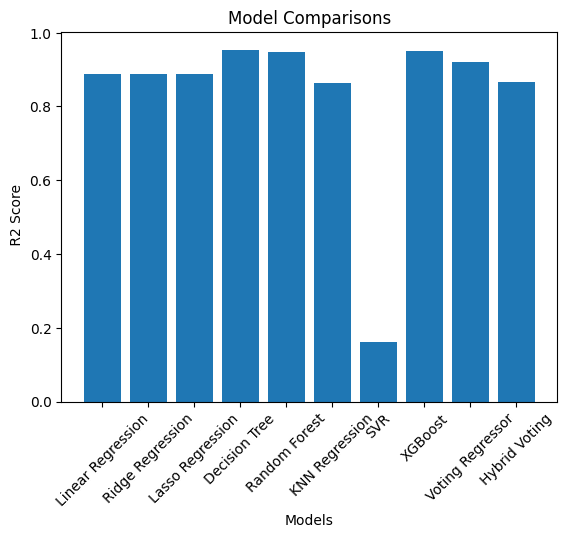

In [85]:
plt.bar(results_df['Model'],results_df['R2 score'])
plt.xlabel('Models')
plt.ylabel(' R2 Score')
plt.title('Model Comparisons')
plt.xticks(rotation=45)
plt.show()

Among all the models, Ridge Regression performed the best with the highest R^2 score and lowest error values.

In [86]:
best = DecisionTreeRegressor()
best.fit(X_train,y_train)
new_electric_bill = np.array([[2, 5, 367.73, 0, 0, 0, 0, 0]])
new_ebill_scaled = scaler.transform(new_electric_bill)
predicted_price = best.predict(new_ebill_scaled)
print("Predicted Price:", predicted_price)

Predicted Price: [937.7238264]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [87]:
import pickle
pickle.dump(best, open('ebill_prediction_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))